# Detuned noisy GPG recovery sweep

Compact one-cell workflow for the detuned `gpgs.py` implementation. Edit the knobs at the top, then run the cell to load/run the sweep, save the CSV, and redraw the plot.


Loaded cache: /Users/46668993/Desktop/qer/datas/noisy_gpgs_pulses/cache/detuned_usual_gpg_p5e-4_p1e-3_Csweep.pkl
running p=0.0005, C=1e+06
  done: GPG=1.817435e-03, below=False
running p=0.0005, C=1e+07
  done: GPG=1.966174e-04, below=True
running p=0.0005, C=1e+08
  done: GPG=1.232385e-04, below=True
running p=0.0005, C=1e+09
  done: GPG=7.203884e-05, below=True
running p=0.0005, C=1e+10
  done: GPG=1.450051e-05, below=True
running p=0.001, C=1e+06
  done: GPG=2.361942e-03, below=False
running p=0.001, C=1e+07
  done: GPG=8.441050e-04, below=True
running p=0.001, C=1e+08
  done: GPG=4.532018e-05, below=True
running p=0.001, C=1e+09
  done: GPG=2.044358e-05, below=True
running p=0.001, C=1e+10
  done: GPG=1.214362e-05, below=True
Saved CSV: /Users/46668993/Desktop/qer/datas/noisy_gpgs_pulses/detuned_usual_gpg_p5e-4_p1e-3_Csweep_metrics.csv
     p  GPG cooperativity  GPG infidelity  error-free GPG infidelity  baseline p  below baseline  max state-prep infidelity
0.0005       1.000000e+0

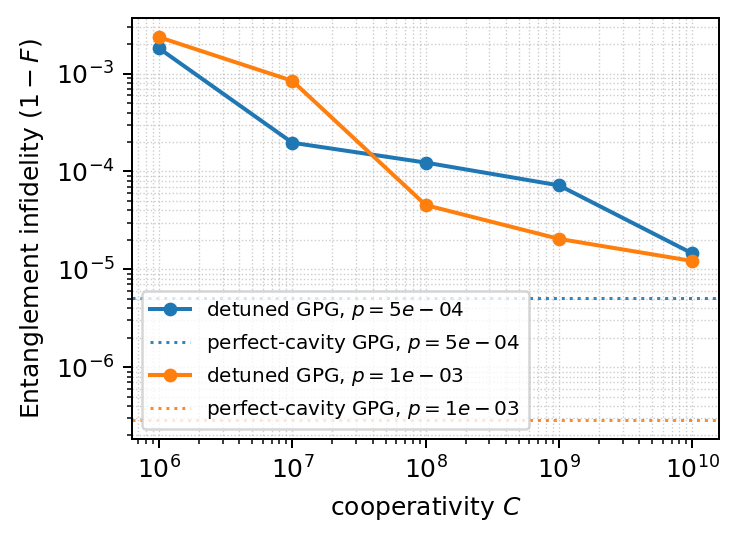

Saved plot: /Users/46668993/Desktop/qer/plots/AD/noisy_gpg_implementation/detuned_usual_gpg_cooperativity_sweep.pdf
Worst state-prep targets for p=1.000000000000e-03|C=1.000000000000e+10|mode=detuned|restarts=3|maxiter=500|complete-prior-v1:
                 factor  eig_index  pulses  1 - F_state  Tr_state  elapsed_s
           feedback U_0          0       9     0.001854  0.999143  29.545849
           feedback U_1          3       8     0.001675  0.999153  27.387641
stage 1 split entangler          2      10     0.001673  0.999086  34.085559
           feedback U_1          0       8     0.001486  0.999255  26.856703
           feedback U_3          2       9     0.001442  0.999275  30.478832
           feedback U_0          1       9     0.001364  0.999353  30.516479
           feedback U_3          3       7     0.001281  0.999333  24.277075
           feedback U_2          5       9     0.001241  0.999291  30.009823
           feedback U_1          1       8     0.001194  0.999407

In [ ]:
from pathlib import Path
import pickle
import sys
import time

import matplotlib.pyplot as plt
import pandas as pd

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "python" / "codes").exists())
sys.path.insert(0, str(repo_root / "python"))

from codes import gpgs
from codes.bk_recovery import petz_recovery_kraus
from codes.codewords import bgmcode_kets_in_top_block
from codes.noisemodel import noisemodel

# ---------------------------- editable knobs ----------------------------
b, g, m = 3, 3, 1
P_VALUES = [5e-4, 1e-3]
COOPERATIVITIES = [1e6, 1e7, 1e8, 1e9, 1e10]
RUN_SWEEP = 1          # Set True to launch missing points; cached points are reused.
USE_CACHE = True
DETUNED_RESTARTS = 3       # Increase for deeper polishing, especially low C.
DETUNED_MAXITER = 500

CACHE_PATH = repo_root / "datas/noisy_gpgs_pulses/cache/detuned_usual_gpg_p5e-4_p1e-3_Csweep.pkl"
CSV_PATH = repo_root / "datas/noisy_gpgs_pulses/detuned_usual_gpg_p5e-4_p1e-3_Csweep_metrics.csv"
PLOT_DIR = repo_root / "plots/AD/noisy_gpg_implementation"
NOISELESS_CACHE_PATH = repo_root / "datas/noiseless_gpgs_pulses/cache/gpg_exact_ad_sweep_cache.pkl"
ERROR_FREE_REF_PATH = repo_root / "datas/noisy_gpgs_pulses/cache/error_free_usual_gpg_refs_p5e-4_p1e-3.pkl"

# ---------------------------- fixed setup ----------------------------
N = 2 * b * m + g
SYSTEM_DIM = N + 1
REFERENCE_WEIGHT = N
ket0, ket1, _ = bgmcode_kets_in_top_block(b, g, m, return_qutip=True)
rho_c = (ket0 * ket0.dag() + ket1 * ket1.dag()) / 2


def exact_global_ad(p):
    return noisemodel(
        "global symmetric amplitude damping", N, float(p), 1.0,
        return_rep="super", dynamics="exact",
    )


def approximate_petz_recovery(p):
    kraus = noisemodel(
        "global symmetric amplitude damping", N, float(p), 1.0,
        return_rep="kraus", dynamics="approx",
    )
    return petz_recovery_kraus(gpgs.restrict_operators_to_dimension(kraus, SYSTEM_DIM), rho_c)


def complete_noiseless_prior_for_p(p):
    """Use refined perfect-cavity pulses first, then fill missing labels from the old sweep."""
    prior, source = {}, {}
    for cache_path in [ERROR_FREE_REF_PATH, NOISELESS_CACHE_PATH]:
        if not cache_path.exists():
            continue
        with cache_path.open("rb") as f:
            old_cache = pickle.load(f)
        old_points = sorted(old_cache["points"].values(), key=lambda point: abs(point["metrics"]["p"] - float(p)))
        for point in old_points:
            source_p = float(point["metrics"]["p"])
            for key, sequence in point["pulse_sequences"].items():
                if key not in prior:
                    prior[key] = sequence
                    source[key] = source_p
    return prior, source


def load_error_free_gpg_refs(p_values):
    """Load perfect-cavity GPG reference infidelities for the plotted p values."""
    refs = {}
    if ERROR_FREE_REF_PATH.exists():
        with ERROR_FREE_REF_PATH.open("rb") as f:
            ref_cache = pickle.load(f)
        for point in ref_cache.get("points", {}).values():
            p_ref = float(point["metrics"]["p"])
            for p in p_values:
                if abs(p_ref - float(p)) <= 1e-15:
                    refs[float(p)] = float(point["metrics"]["GPG infidelity"])

    missing = [float(p) for p in p_values if float(p) not in refs]
    if missing:
        with NOISELESS_CACHE_PATH.open("rb") as f:
            old_cache = pickle.load(f)
        old_points = list(old_cache["points"].values())
        for p in missing:
            nearest = min(old_points, key=lambda point: abs(float(point["metrics"]["p"]) - p))
            refs[p] = float(nearest["metrics"]["GPG infidelity"])
            print(
                f"Warning: using nearest old error-free GPG reference for p={p:g}: "
                f"p_ref={nearest['metrics']['p']:.6g}"
            )
    return refs


def detuned_usual_settings(label, eig_index, counter):
    settings = gpgs.default_gpg_recovery_settings(label, eig_index, counter).copy()
    settings["restarts"] = DETUNED_RESTARTS
    settings["maxiter"] = DETUNED_MAXITER
    return settings


def cache_key(p, C):
    return (
        f"p={float(p):.12e}|C={float(C):.12e}|mode=detuned"
        f"|restarts={DETUNED_RESTARTS}|maxiter={DETUNED_MAXITER}|complete-prior-v1"
    )


def run_point(p, C, log=None):
    prior, source = complete_noiseless_prior_for_p(p)
    t0 = time.perf_counter()
    point = gpgs.run_gpg_recovery(
        rho_c,
        exact_global_ad,
        approximate_petz_recovery,
        float(p),
        logical_kets=(ket0, ket1),
        reference_weight=REFERENCE_WEIGHT,
        prior_sequences=prior,
        settings_fn=detuned_usual_settings,
        gpg_mode="detuned",
        cooperativity=float(C),
        log=log,
    )
    point["metrics"]["baseline p"] = float(p)
    point["metrics"]["below baseline"] = bool(point["metrics"]["GPG infidelity"] < float(p))
    point["metrics"]["wall seconds"] = float(time.perf_counter() - t0)
    point["prior_source_p"] = source
    return point


# ---------------------------- run/load sweep ----------------------------
cache = {"points": {}}
if USE_CACHE and CACHE_PATH.exists():
    with CACHE_PATH.open("rb") as f:
        cache = pickle.load(f)
    print(f"Loaded cache: {CACHE_PATH}")

rows = []
for p in P_VALUES:
    for C in COOPERATIVITIES:
        key = cache_key(p, C)
        if key in cache["points"]:
            point = cache["points"][key]
            print(f"cached p={p:g}, C={C:g}: GPG={point['metrics']['GPG infidelity']:.6e}")
        elif RUN_SWEEP:
            print(f"running p={p:g}, C={C:g}")
            point = run_point(p, C, log=None)
            cache["points"][key] = point
            CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
            with CACHE_PATH.open("wb") as f:
                pickle.dump(cache, f)
            print(f"  done: GPG={point['metrics']['GPG infidelity']:.6e}, below={point['metrics']['below baseline']}")
        else:
            print(f"missing p={p:g}, C={C:g}; set RUN_SWEEP=True to run")
            continue
        rows.append(point["metrics"])

metrics = pd.DataFrame(rows).sort_values(["p", "GPG cooperativity"]).reset_index(drop=True) if rows else pd.DataFrame()
if metrics.empty:
    print("No completed sweep points available.")
else:
    CSV_PATH.parent.mkdir(parents=True, exist_ok=True)
    error_free_refs = load_error_free_gpg_refs(P_VALUES)
    metrics["error-free GPG infidelity"] = metrics["p"].map(lambda value: error_free_refs[float(value)])
    metrics.to_csv(CSV_PATH, index=False)
    summary_cols = ["p", "GPG cooperativity", "GPG infidelity", "error-free GPG infidelity", "baseline p", "below baseline", "max state-prep infidelity"]
    summary = metrics[summary_cols]
    print(f"Saved CSV: {CSV_PATH}")
    print(summary.to_string(index=False))

    PLOT_DIR.mkdir(parents=True, exist_ok=True)
    fig, ax = plt.subplots(figsize=(4.2, 3.1), dpi=180)
    colors = {5e-4: "tab:blue", 1e-3: "tab:orange"}
    for p, group in metrics.groupby("p"):
        group = group.sort_values("GPG cooperativity")
        color = colors.get(float(p))
        ax.loglog(group["GPG cooperativity"], group["GPG infidelity"], "o-", lw=1.6, ms=4.5, color=color, label=rf"detuned GPG, $p={float(p):.0e}$")
        ax.axhline(
            error_free_refs[float(p)],
            color=color,
            ls=":",
            lw=1.2,
            alpha=0.9,
            label=rf"perfect-cavity GPG, $p={float(p):.0e}$",
        )
    ax.set_xlabel(r"cooperativity $C$")
    ax.set_ylabel(r"Entanglement infidelity $(1-F)$")
    ax.grid(True, which="both", ls=":", lw=0.55, alpha=0.65)
    ax.legend(frameon=True, fontsize=8)
    fig.tight_layout()
    pdf_path = PLOT_DIR / "detuned_usual_gpg_cooperativity_sweep.pdf"
    png_path = PLOT_DIR / "detuned_usual_gpg_cooperativity_sweep.png"
    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, bbox_inches="tight")
    try:
        display(fig)
    except NameError:
        pass
    plt.close(fig)
    print(f"Saved plot: {pdf_path}")

    selected_key = list(cache["points"].keys())[-1]
    worst = pd.DataFrame(cache["points"][selected_key]["optimization_records"]).sort_values("1 - F_state", ascending=False)
    print(f"Worst state-prep targets for {selected_key}:")
    print(worst[["factor", "eig_index", "pulses", "1 - F_state", "Tr_state", "elapsed_s"]].head(12).to_string(index=False))



## Current plot

![Detuned noisy GPG cooperativity sweep](../../plots/AD/noisy_gpg_implementation/detuned_usual_gpg_cooperativity_sweep.png)


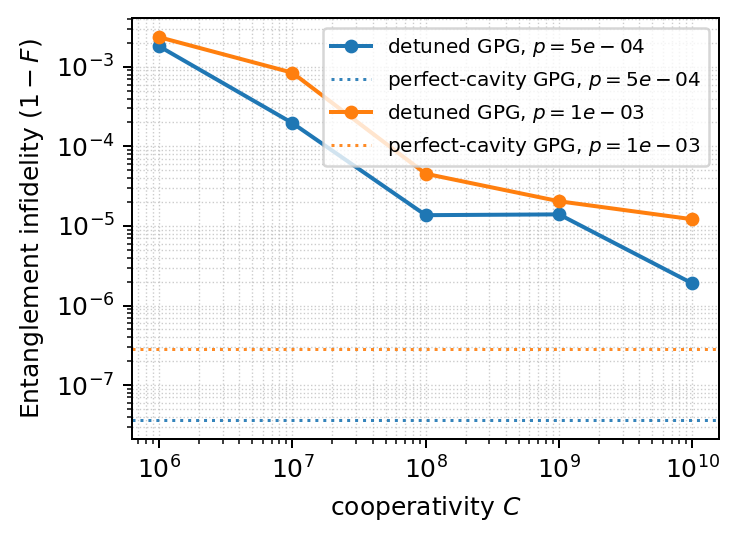

In [1]:
# Display the latest saved noisy-GPG cooperativity plot
from pathlib import Path
from IPython.display import Image, display

plot_path = Path('../../plots/AD/noisy_gpg_implementation/detuned_usual_gpg_cooperativity_sweep.png')
display(Image(filename=str(plot_path)))
